In [1]:
import numpy as np
import matplotlib.pyplot as plt
import csv
import pandas as pd
from pathlib import Path
from tkinter import filedialog
import seaborn as sns
import itertools
from colour import Color
from datetime import date
import tifffile
import scipy  as spy
from skimage import filters

In [2]:
today = date.today()
print("Today's date:", today)
date_today = str(today)
date_today

Today's date: 2022-05-23


'2022-05-23'

In [3]:
askdirectory = filedialog.askdirectory() # show an "Open" dialog box and return the path to the folder on ONE date you want to process
path = Path(askdirectory)
path

WindowsPath('D:/Sofia/2022_1winter/2022-05-11_control_flowin_phalloidin_taxol/CH1_DCX2nM_TypeWT_tax0uM')

In [4]:
folders = [x for x in path.iterdir() if x.is_dir()]
folders = [i for i in folders if str(i).rfind('Kymo') != -1]
folders

[WindowsPath('D:/Sofia/2022_1winter/2022-05-11_control_flowin_phalloidin_taxol/CH1_DCX2nM_TypeWT_tax0uM/Kymographs-1-Stream_ctl_Composite-GFP'),
 WindowsPath('D:/Sofia/2022_1winter/2022-05-11_control_flowin_phalloidin_taxol/CH1_DCX2nM_TypeWT_tax0uM/Kymographs-1-Stream_ctl_Composite_RFP')]

In [43]:
files = []

for i in folders:
    if str(i).rfind('GFP') != -1 :
        GFP_files = [x for x in i.iterdir() if x.is_file()]
        
    if str(i).rfind('RFP') != -1 :
        RFP_files = [x for x in i.iterdir() if x.is_file()]

GFP_files

[WindowsPath('D:/Sofia/2022_1winter/2022-05-11_control_flowin_phalloidin_taxol/CH1_DCX2nM_TypeWT_tax0uM/Kymographs-1-Stream_ctl_Composite-GFP/Kymograph_001_0500-0385-0416.tif'),
 WindowsPath('D:/Sofia/2022_1winter/2022-05-11_control_flowin_phalloidin_taxol/CH1_DCX2nM_TypeWT_tax0uM/Kymographs-1-Stream_ctl_Composite-GFP/Kymograph_002_0001-0279-0213.tif'),
 WindowsPath('D:/Sofia/2022_1winter/2022-05-11_control_flowin_phalloidin_taxol/CH1_DCX2nM_TypeWT_tax0uM/Kymographs-1-Stream_ctl_Composite-GFP/Kymograph_003_0497-0353-0191.tif'),
 WindowsPath('D:/Sofia/2022_1winter/2022-05-11_control_flowin_phalloidin_taxol/CH1_DCX2nM_TypeWT_tax0uM/Kymographs-1-Stream_ctl_Composite-GFP/Kymograph_004_0497-0111-0181.tif'),
 WindowsPath('D:/Sofia/2022_1winter/2022-05-11_control_flowin_phalloidin_taxol/CH1_DCX2nM_TypeWT_tax0uM/Kymographs-1-Stream_ctl_Composite-GFP/Kymograph_005_0497-0334-0415.tif'),
 WindowsPath('D:/Sofia/2022_1winter/2022-05-11_control_flowin_phalloidin_taxol/CH1_DCX2nM_TypeWT_tax0uM/Kymogr

## Get Metadata ##

In [6]:
DCXconc = '[DCX] ' r'$(n M)$'

Type = 'DCX Type'

taxol = '[Taxol] ' r'$(\mu M)$'

In [7]:
i = path

dateloc = str(i).rfind("202")

CHloc = str(i).find("CH")
CHlocend = str(i).find('_', CHloc)

taxloc = str(i).rfind('tax')
taxlocend = str(i).find('uM', taxloc)

DCXloc = str(i).rfind('DCX')
DCXlocend = str(i).find('nM', DCXloc)

dcxtypeloc = str(i).find("Type")
dcxtypelocend = str(i).find('_', dcxtypeloc)

date = str(path)[dateloc : dateloc+10]
ch = str(i)[CHloc+2:CHlocend]
conc_tax = str(i)[taxloc+3:taxlocend]
conc_DCX = str(i)[DCXloc+3:DCXlocend]
DCX_type = str(i)[dcxtypeloc+4:dcxtypelocend]

conc_tax = float(conc_tax)
conc_DCX = float(conc_DCX)

date,ch, conc_tax, conc_DCX, DCX_type

('2022-05-11', '1', 0.0, 2.0, 'WT')

## Open kymograph ##

In [44]:
kymoR = tifffile.imread(RFP_files[0])
kymoG = tifffile.imread(GFP_files[0])

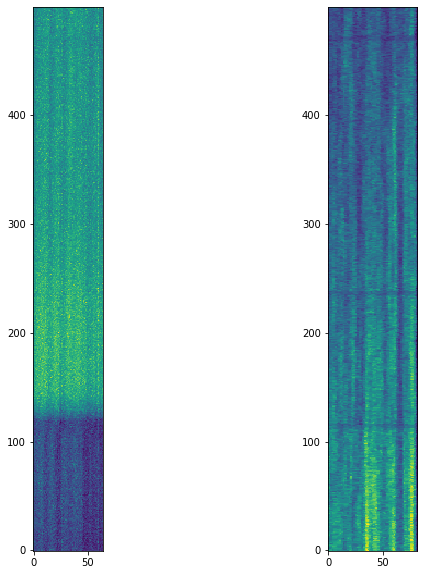

In [45]:
fig, ax = plt.subplots(1,2,figsize=(10,10))

ax[0].imshow(kymoR, interpolation='none', origin=[0, 0], cmap='viridis')
ax[1].imshow(kymoG, interpolation='none', origin=[0, 0], cmap='viridis')

In [173]:
def kymo_mean(files,roll):
    
    mean_kymo = []
    
    for i in files:
        kymo = tifffile.imread(i)
        mean_kymo = mean_kymo + [np.mean(kymo, axis=1)]
        
    mean_all_kymo = np.mean(mean_kymo, axis=0)
    
    result = pd.DataFrame({'Time (s)': np.arange(len(mean_all_kymo))/10, 'Intensity': mean_all_kymo})
    result['Normal Intensity'] =  normalize(mean_all_kymo)  
    result['Rolling Intensity'] =  result['Intensity'].rolling(roll, min_periods=1, center=True).mean()
    result['Rolling Intensity std'] =  result['Intensity'].rolling(roll, min_periods=1, center=True).std()
    
    array = result['Rolling Intensity'].values
    result['Normal Rolling Intensity'] =  (array - min(array)) / (max(array) - min(array))
    result['Normal Rolling Intensity std'] = result['Rolling Intensity std']/(max(array) - min(array))
    
    fill_top = 
        
    return result

In [192]:
roll =  10
allRFP= kymo_mean(RFP_files,roll)
allRFP['Channel'] = 'RFP'
allGFP= kymo_mean(GFP_files,roll)
allGFP['Channel'] = 'GFP'


In [193]:
def get_values(data):
    x = data['Time (s)'].values
    mean = data['Normal Rolling Intensity'].values
    std = data['Normal Rolling Intensity std'].values
    return x, mean, std

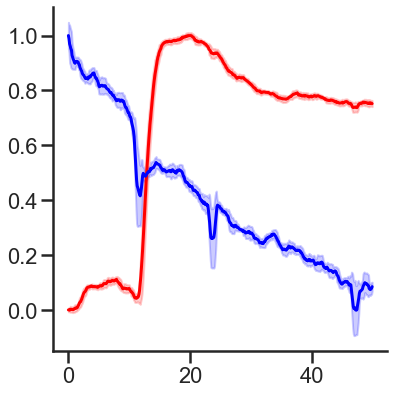

In [194]:
plt.figure(figsize=(6, 6))

x, mean, std = get_values(allRFP)
plt.plot(x, mean, 'r-')
plt.fill_between(x, mean - std, mean + std, color='r', alpha=0.2)

x, mean, std = get_values(allGFP)
plt.plot(x, mean, 'b-')
plt.fill_between(x, mean - std, mean + std, color='B', alpha=0.2)


sns.set_style("ticks")
sns.despine()
sns.set_context("poster", font_scale=1, rc={"lines.linewidth":3.0})

plt.tight_layout()

## Save data ##

In [195]:
newdirectory = str(path.parents[1])+'//Photobleaching_Data_Sheets'
newmydir = Path(newdirectory)
newmydir.mkdir(exist_ok=True)

In [196]:
data.to_csv(path/(dates+'_'+CH+'_phototbleach_analysed-on_'+date_today +'.csv'), encoding='utf-8', index=False)
data.to_csv(newmydir/(dates+'_'+CH+'_phototbleach_analysed-on_'+date_today+'.csv'), encoding='utf-8', index=False)

NameError: name 'data' is not defined